ML:
1. Wasserstein: 3 pairs: (b_0(f),b_0(g)) (b_0^1(f),b_0^1(g)) (b_1(f)U b_2(g),b_1(g) Ub_2(f))
2. Persistence Image: Gassusian +b_1 - b_2

In [1]:
import sys
sys.path.append('/root/Codes/graph-mph0/build')
import abmph
import numpy as np

In [10]:

np.random.seed(20)
n_nodes = 4
n_edges = 10
nodes = np.arange(1, n_nodes+1, dtype=int)
edges = np.random.randint(1, n_nodes+1, size=(n_edges, 2))
node_features = np.zeros(shape=(n_nodes, 2), dtype = np.double)
edge_features = np.random.randint(1, 10, size=(n_edges, 2)).astype(np.double)
edge_str_labels = [f"({int(row[0])},{int(row[1])})" for row in edge_features]
# edge_labels = {(row[0],row[1]):  edge_str_labels[i] for i, row in enumerate(edges) }
# edges, edge_features, edge_str_labels, edge_labels
nodes, edges

(array([1, 2, 3, 4]),
 array([[4, 3],
        [4, 4],
        [1, 3],
        [2, 1],
        [4, 3],
        [4, 3],
        [1, 3],
        [1, 2],
        [3, 3],
        [4, 4]]))

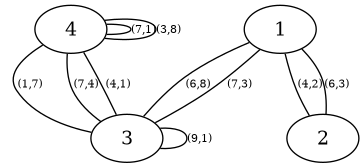

In [11]:
import pygraphviz as pgv
import matplotlib.pyplot as plt
from PIL import Image
# Create a new AGraph (directed graph)
G = pgv.AGraph(strict=False, directed=False)

for i, row in enumerate(edges):
    G.add_edge(row[0], row[1], label=edge_str_labels[i])
    
# Draw the graph to a file
G.layout(prog='dot',args="-Efontsize=8")  # Use the 'dot' layout engine
G.draw('graph.png')

# Display the graph using PIL
img = Image.open('graph.png')
img.show()

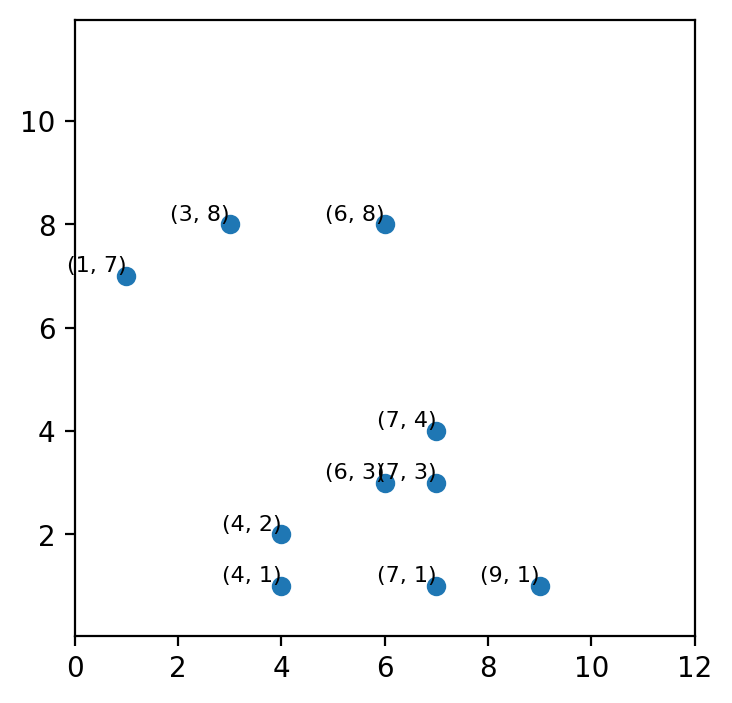

In [12]:
plt.figure(figsize=(4, 4), dpi=200)

plt.scatter(edge_features[:,0], edge_features[:,1])
plt.axis('equal')
plt.xlim(0, 12)
plt.ylim(0, 12)
# Annotate each point with its (x, y) coordinates
for i in range(len(edge_features)):
    x, y = edge_features[i, 0], edge_features[i, 1]
    plt.text(x, y, f'({int(x)}, {int(y)})', fontsize=8, ha='right', va='bottom')


In [13]:
# Create the Graph object
mph_g = abmph.Graph(nodes, node_features, edges, edge_features)

In [14]:
mph_g.print_adjacency()

Print Adjacency
v = 2: Edge(1, 2, id = 4) Edge(1, 2, id = 8) 
v = 1: Edge(1, 3, id = 3) Edge(1, 2, id = 4) Edge(1, 3, id = 7) Edge(1, 2, id = 8) 
v = 4: Edge(3, 4, id = 1) Edge(4, 4, id = 2) Edge(4, 4, id = 2) Edge(3, 4, id = 5) Edge(3, 4, id = 6) Edge(4, 4, id = 10) Edge(4, 4, id = 10) 
v = 3: Edge(3, 4, id = 1) Edge(1, 3, id = 3) Edge(3, 4, id = 5) Edge(3, 4, id = 6) Edge(1, 3, id = 7) Edge(3, 3, id = 9) Edge(3, 3, id = 9) 


In [15]:
mph_g.print_filtration_value()

Graph filtration values:
Vertices:
f(1) = (0, 0)
f(2) = (0, 0)
f(3) = (0, 0)
f(4) = (0, 0)
edge_values:
e = Edge(4, 4, id = 10), f(e)= (3, 8)
e = Edge(3, 3, id = 9), f(e)= (9, 1)
e = Edge(1, 2, id = 8), f(e)= (4, 2)
e = Edge(1, 3, id = 7), f(e)= (7, 3)
e = Edge(3, 4, id = 6), f(e)= (4, 1)
e = Edge(3, 4, id = 5), f(e)= (7, 4)
e = Edge(1, 2, id = 4), f(e)= (6, 3)
e = Edge(1, 3, id = 3), f(e)= (6, 8)
e = Edge(4, 4, id = 2), f(e)= (7, 1)
e = Edge(3, 4, id = 1), f(e)= (1, 7)


In [16]:
abmph.compute_MPH0_Dengrogram(mph_g)

{'b_0': [(0.0, 0.0)],
 'b_1': [(1.0, 7.0), (4.0, 1.0), (4.0, 2.0), (6.0, 8.0), (7.0, 3.0)],
 'b_2': [(4.0, 7.0), (7.0, 8.0)],
 'b_0_1': [(3.0, 8.0),
  (4.0, 7.0),
  (6.0, 3.0),
  (7.0, 1.0),
  (7.0, 8.0),
  (7.0, 4.0),
  (9.0, 1.0)],
 'M': [(1, 1, -1),
  (1, 1, 1),
  (1, 2, -1),
  (1, 2, 1),
  (1, 3, -1),
  (1, 3, 1),
  (1, 4, -1),
  (1, 4, 1),
  (1, 5, -1),
  (1, 5, 1)]}

In [17]:
abmph.compute_MPH0_DTree(mph_g)

{'b_0': [(0.0, 0.0)],
 'b_1': [(1.0, 7.0), (4.0, 1.0), (4.0, 2.0), (6.0, 8.0), (7.0, 3.0)],
 'b_2': [(4.0, 7.0), (7.0, 8.0)],
 'b_0_1': [(3.0, 8.0),
  (4.0, 7.0),
  (6.0, 3.0),
  (7.0, 1.0),
  (7.0, 8.0),
  (7.0, 4.0),
  (9.0, 1.0)],
 'M': [(1, 1, -1),
  (1, 1, 1),
  (1, 2, -1),
  (1, 2, 1),
  (1, 3, -1),
  (1, 3, 1),
  (1, 4, -1),
  (1, 4, 1),
  (1, 5, -1),
  (1, 5, 1)]}

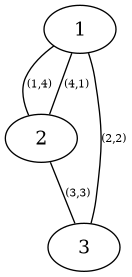

In [10]:
import sys
sys.path.append('/root/Codes/graph-mph0/build/')
import abmph
import numpy as np
import pygraphviz as pgv
import matplotlib.pyplot as plt
from PIL import Image
n_nodes = 3

nodes = np.arange(1, n_nodes+1, dtype=int)
edges = np.array([[1,2], [1,2], [1,3], [2,3]], dtype=int)
node_features = np.zeros(shape=(n_nodes, 2), dtype = np.double)
edge_features = np.array([[1.,4.], [4.,1.], [2.,2.], [3.,3.]], dtype = np.double)
edge_str_labels = [f"({int(row[0])},{int(row[1])})" for row in edge_features]

# Create a new AGraph (directed graph)
G = pgv.AGraph(strict=False, directed=False)

for i, row in enumerate(edges):
    G.add_edge(row[0], row[1], label=edge_str_labels[i])
    
# Draw the graph to a file
G.layout(prog='dot',args="-Efontsize=8")  # Use the 'dot' layout engine
G.draw('graph.png')

# Display the graph using PIL
img = Image.open('graph.png')
img.show()

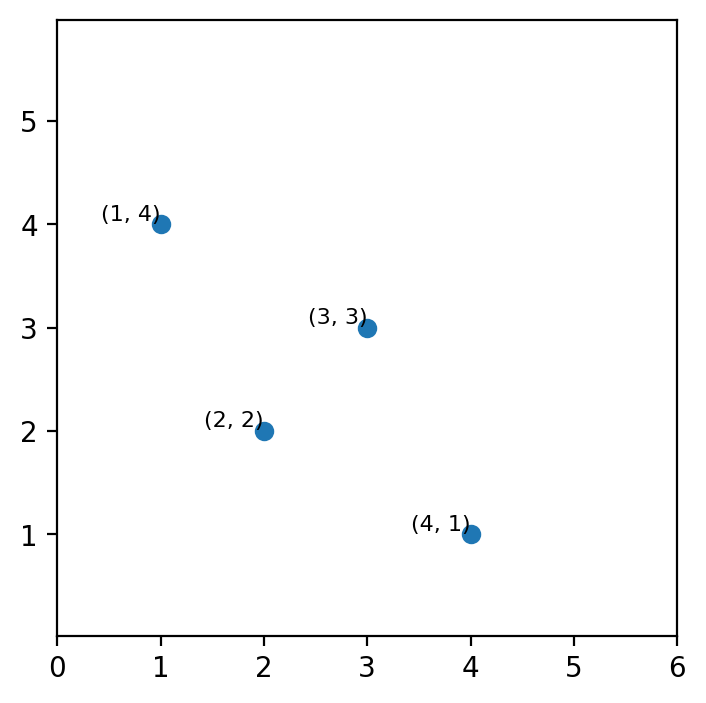

In [11]:

plt.figure(figsize=(4, 4), dpi=200)
plt.scatter(edge_features[:,0], edge_features[:,1])
plt.axis('equal')
plt.xlim(0, 6)
plt.ylim(0, 6)
# Annotate each point with its (x, y) coordinates
for i in range(len(edge_features)):
    x, y = edge_features[i, 0], edge_features[i, 1]
    plt.text(x, y, f'({int(x)}, {int(y)})', fontsize=8, ha='right', va='bottom')

In [12]:
mph_g = abmph.Graph(nodes, node_features, edges, edge_features)
mph_g.print_adjacency()
mph_g.print_filtration_value()

Print Adjacency
v = 3: Edge(1, 3, id = 3) Edge(2, 3, id = 4) 
v = 2: Edge(1, 2, id = 1) Edge(1, 2, id = 2) Edge(2, 3, id = 4) 
v = 1: Edge(1, 2, id = 1) Edge(1, 2, id = 2) Edge(1, 3, id = 3) 
Graph filtration values:
Vertices:
f(1) = (0, 0)
f(2) = (0, 0)
f(3) = (0, 0)
edge_values:
e = Edge(2, 3, id = 4), f(e)= (3, 3)
e = Edge(1, 3, id = 3), f(e)= (2, 2)
e = Edge(1, 2, id = 2), f(e)= (4, 1)
e = Edge(1, 2, id = 1), f(e)= (1, 4)


In [13]:
abmph.compute_MPH0_Dengrogram(mph_g)

{'b_0': [(0.0, 0.0)],
 'b_1': [(1.0, 4.0), (2.0, 2.0), (3.0, 3.0), (4.0, 1.0)],
 'b_2': [(3.0, 4.0), (4.0, 3.0)],
 'b_0_1': [(3.0, 4.0), (4.0, 3.0)],
 'M': [(1, 1, -1),
  (1, 1, 1),
  (1, 2, -1),
  (1, 2, 1),
  (1, 3, -1),
  (1, 3, 1),
  (1, 4, -1),
  (1, 4, 1)]}

In [14]:
abmph.compute_MPH0_DTree(mph_g)

{'b_0': [(0.0, 0.0)],
 'b_1': [(1.0, 4.0), (2.0, 2.0), (3.0, 3.0), (4.0, 1.0)],
 'b_2': [(3.0, 4.0), (4.0, 3.0)],
 'b_0_1': [(3.0, 4.0), (4.0, 3.0)],
 'M': [(1, 1, -1),
  (1, 1, 1),
  (1, 2, -1),
  (1, 2, 1),
  (1, 3, -1),
  (1, 3, 1),
  (1, 4, -1),
  (1, 4, 1)]}

## dgl graph to mph graph

In [1]:
import dgl
import torch
import torch.nn as nn
import torch.nn.functional as F
import dgl.data
import numpy as np
dataset = dgl.data.TUDataset(name = 'Cuneiform', raw_dir='../data')
print('Number of categories:', dataset.num_classes)

/root/miniconda3/envs/dl/lib/python3.10/site-packages/torchdata/datapipes/__init__.py:18: UserWarning: 
################################################################################
WARNING!
The 'datapipes', 'dataloader2' modules are deprecated and will be removed in a
future torchdata release! Please see https://github.com/pytorch/data/issues/1196
to learn more and leave feedback.
################################################################################

  deprecation_warning()
/root/miniconda3/envs/dl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of categories: 30


In [2]:
len(dataset)

267

In [3]:
g, label = dataset[0]
g

Graph(num_nodes=36, num_edges=180,
      ndata_schemes={'_ID': Scheme(shape=(), dtype=torch.int64), 'node_attr': Scheme(shape=(3,), dtype=torch.float64), 'node_labels': Scheme(shape=(2,), dtype=torch.int64)}
      edata_schemes={'_ID': Scheme(shape=(), dtype=torch.int64), 'node_labels': Scheme(shape=(2,), dtype=torch.float64), 'edge_labels': Scheme(shape=(1,), dtype=torch.int64)})

In [4]:
g.nodes().numpy()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35])

In [19]:
e_0s, e_1s, e_ids = g.edges(form='all',  order='srcdst')
e_0s

tensor([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  2,  2,  2,  3,
         3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,  5,  5,  6,  6,
         6,  7,  7,  7,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  9,  9,  9,
        10, 10, 10, 11, 11, 11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13,
        13, 13, 14, 14, 14, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
        16, 17, 17, 17, 18, 18, 18, 19, 19, 19, 20, 20, 20, 20, 20, 20, 20, 20,
        20, 20, 20, 21, 21, 21, 22, 22, 22, 23, 23, 23, 24, 24, 24, 24, 24, 24,
        24, 24, 24, 24, 24, 25, 25, 25, 26, 26, 26, 27, 27, 27, 28, 28, 28, 28,
        28, 28, 28, 28, 28, 28, 28, 29, 29, 29, 30, 30, 30, 31, 31, 31, 32, 32,
        32, 32, 32, 32, 32, 32, 32, 32, 32, 33, 33, 33, 34, 34, 34, 35, 35, 35])

In [20]:
from sklearn.preprocessing import StandardScaler

node_labels = g.nodes().numpy()
node_features = np.zeros((node_labels.shape[0], 2))
edges_input = np.vstack((e_0s.numpy(), e_1s.numpy())).T
# Create a StandardScaler object
scaler = StandardScaler()
edge_features = scaler.fit_transform(g.edata['node_labels'].numpy())

In [12]:
np.save("../data/node_labels.npy", node_labels)
np.save("../data/node_features.npy", node_features)
np.save("../data/edges_input.npy", edges_input)
np.save("../data/edge_features.npy", edge_features)

In [7]:
def standardize_array(arr):
    # Step 1: Normalize to [0, 1]
    arr_min = np.min(arr)
    arr_max = np.max(arr)
    arr_normalized = (arr - arr_min) / (arr_max - arr_min)

    # Step 2: Adjust standard deviation to 1
    arr_std = np.std(arr_normalized)
    arr_standardized = arr_normalized / arr_std
    return arr_standardized


node_labels = np.load("../data/node_labels.npy")
node_features = np.zeros((node_labels.shape[0], 2))
edges_input = np.load("../data/edges_input.npy")
edge_features = standardize_array(np.load("../data/edge_features.npy"))

g2 = abmph.Graph(node_labels, node_features, edges_input, edge_features)

In [8]:
res_den = abmph.compute_MPH0_Dengrogram(g2)

In [9]:
res_dt = abmph.compute_MPH0_DTree(g2)

In [10]:
len(res_den['b_1']), len(res_dt['b_1'])

(54, 48)

In [11]:
for a, b in zip(res_den['b_1'][:48], res_dt['b_1']):
    if a != b:
        print(a,b)

(2.4906396878858277, 1.4538509005123137) (2.879628908574195, 6.105255591499731)
(2.605780826585407, 2.6909645718459183) (2.925679931379595, 4.19070045755796)
(2.7481675268155215, 2.28898676551305) (2.9587151046405706, 5.097774863702103)
(2.879628908574195, 6.105255591499731) (2.9660855677466023, 5.1326612021857985)
(2.925679931379595, 4.19070045755796) (3.0680666316097094, 3.7887226512250924)
(2.9587151046405706, 5.097774863702103) (3.5075978508405776, 1.4840702099457215)
(2.9660855677466023, 5.1326612021857985) (3.548003487207585, 2.426030954573559)
(3.0680666316097094, 3.7887226512250924) (3.5537930989380246, 4.972196838384174)
(3.343245521112976, 2.163408740195121) (3.5940545100129846, 0.5114758206317899)
(3.5075978508405776, 1.4840702099457215) (3.6227389895401565, 2.7211838812793263)
(3.548003487207585, 2.426030954573559) (3.663144625907164, 3.663144625907164)
(3.5537930989380246, 4.972196838384174) (3.663144625907164, 3.663144625907164)
(3.5940545100129846, 0.5114758206317899) (3